## Import libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoConfig
import os
from huggingface_hub import login
import re
from spellchecker import SpellChecker

In [61]:
# increase the width of the display to show more columns
pd.set_option("display.max_colwidth", None)

## load data

In [62]:
df = pd.read_csv('v1.csv')

In [63]:
df.shape

(168653, 1)

In [64]:
df.head

<bound method NDFrame.head of                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              Text
0                                                                                                                                                                                                                                                                                                       

In [65]:
# check for missing values\
df.isnull().sum()

Text    0
dtype: int64

In [66]:
# check for duplicates across all columns
print(df.duplicated().sum())
# drop duplicates
df = df.drop_duplicates()

# the data corpus contains text in algerian darija, some are written in arabic letters and some in latin letters, let's calculate the percentages
df['Text'].apply(lambda x: 'arabic' if any('\u0600' <= c <= '\u06FF' for c in x) else 'latin').value_counts(normalize=True) * 100
print("Percentage of Arabic text: {:.2f}%".format(df['Text'].apply(lambda x: 'arabic' if any('\u0600' <= c <= '\u06FF' for c in x) else 'latin').value_counts(normalize=True).get('arabic', 0) * 100))
print("Percentage of Latin text: {:.2f}%".format(df['Text'].apply(lambda x: 'arabic' if any('\u0600' <= c <= '\u06FF' for c in x) else 'latin').value_counts(normalize=True).get('latin', 0) * 100))
# percentage of Arabic text: 82.63%
# percentage of Latin text: 17.37%
# we will split it later, and use each one in a different stage

682
Percentage of Arabic text: 82.63%
Percentage of Latin text: 17.37%


In [67]:
# print the new shape of the dataframe after dropping duplicates
df.shape

(167971, 1)

# filtering out pure arabic sentences

In [68]:
# I noticed many examples are in pure arabic not algerian darija, se we will use a mask of words that appear only in pure arabic to filter them out, we also use a darija mask for safety so that even if the example contains some arabic specific words we dont eleminate it
msa_markers = [
    "أيها",
    "أيتها",
    "لكي",
    "ذلك",
    "تلك",
    "هؤلاء",
    "هناك",
    "هنالك",
    "إذ",
    "إذًا",
    "حيثما",
    "كيفما",
    "كلما",
    "بينما",
    "لذلك",
    "لذلكم",
    "بالتالي",
    "بموجب",
    "بناءً",
    "فضلاً",
    "خصوصًا",
    "سيما",
    "لاسيما",
    "إنما",
    "إنه",
    "إنها",
    "إنهم",
    "إنهن",
    "إنني",
    "إننا",
    "كذلك",
    "هكذا",
    "حينئذ",
    "آنذاك",
    "عندما",
    "عندئذ",
    "منذ",
    "بيد أن",
    "غير أن",
    "إلا أن",
]
darija_markers = [
    # Pronouns / question words
    "واش",
    "شكون",
    "وشكون",
    "وين",
    "فين",
    "علاش",
    "علاه",
    "كيفاش",
    "واشكون",

    # Common Algerian verbal forms
    "راك",
    "راكي",
    "راكم",
    "راهم",
    "راهو",
    "راهي",
    "راني",
    "رانا",
    "راكم",
    "راهم",

    # Common negation / constructions
    "ماشي",
    "ماكانش",
    "مكانش",
    "ماعلاباليش",
    "مانيش",
    "مانيش",
    "مارانيش",
    "ماشيش",
    "مزال",
    "مازال",
    "مزال",

    # Very common Algerian vocabulary
    "بزاف",
    "بصح",
    "دروك",
    "درك",
    "دوك",
    "نتاع",
    "تاع",
    "هاذي",
    "هادي",
    "هاذا",
    "هذا",
    "هاذو",
    "هادو",
    "هاذوك",
    "هادوك",

    # Common colloquial connectors / expressions
    "كاين",
    "كاينة",
    "كاينين",
    "كاينش",
    "خاطر",
    "خاطرش",
    "علىخاطر",
    "كيما",
    "كي",
    "حتى",
    "باش",
    "غير",
    "برك",
    "خلاص",
    "صح",
    "صحا",
    "صحيّت",
    "واش راك",

    # Algerian demonstrative / colloquial forms
    "هكا",
    "هكدا",
    "هكذا",
    "هك",
    "هاك",
    "هاكي",
    "هاكم",
    "هاهم",

    # Common Algerian forms
    "نحب",
    "تحب",
    "يحب",
    "نقدر",
    "تقدر",
    "يقدر",
    "نروح",
    "تروح",
    "يروح",
    "نجي",
    "تجي",
    "يجي",
    "نشوف",
    "تشوف",
    "يشوف",

    # Common Algerian lexical items
    "قاع",
    "صحيت",
    "سما",
    "إيه",
    "ايه",
    "واه",
    "وايه",
    "آه",
    "لالا",
    "لا لا",
    "يخي",
    "مالا",
    "مبعد",
    "منبعد",
    "قبل",
    "غدوة",
    "البارح",
    "اليوم",
    "دزاير",
    "جزاير",
    "جزائري",
    "جزائرية",
    "جزايري",
    "جزايرية",
]
# alright lets find first the examples that contain msa markers
df_msa = df[df["Text"].str.contains("|".join(msa_markers), case=False, na=False)]
print("Number of examples containing MSA markers: {}".format(len(df_msa))) # 5603
# now lets find the examples that contain darija markers from the msa examples
df_msa_darija = df_msa[df_msa["Text"].str.contains("|".join(darija_markers), case=False, na=False)]
print("Number of examples containing both MSA and Darija markers: {}".format(len(df_msa_darija))) # 3945
# so actually the safety mask was useful, we will drop the examples that contain msa markers but not darija markers
#first we need df_msa - df_msa_darija to get the examples that contain msa markers but not darija markers
df_msa_only = df_msa[~df_msa.index.isin(df_msa_darija.index)]
print("Number of examples containing only MSA markers: {}".format(len(df_msa_only)))
# remove these examples from the original dataframe
df = df[~df.index.isin(df_msa_only.index)]

Number of examples containing MSA markers: 5603
Number of examples containing both MSA and Darija markers: 3945
Number of examples containing only MSA markers: 1658


In [69]:
df.shape

(166313, 1)

0


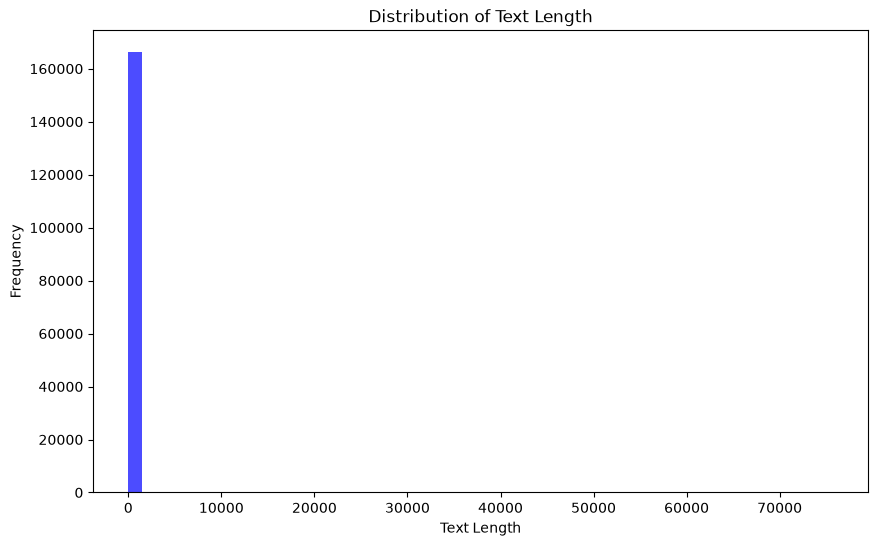

Text Length Statistics:
Mean: 81.42
Median: 52.00
Standard Deviation: 490.65
Minimum: 11
Maximum: 75726
25th Percentile: 38.0
50th Percentile (Median): 52.0
75th Percentile: 80.0
90th Percentile: 129.0
95th Percentile: 179.0
99th Percentile: 363.0


In [70]:
# let's check for empty strings in the Text columns
print((df['Text'] == '').sum()) # no empty strings found
# let's also check for the length distribution of the text column
df['Text_length'] = df['Text'].apply(len)
# plot the distribution of the text length
plt.figure(figsize=(10, 6))
plt.hist(df['Text_length'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()
# let's use df.describe() to get the counts of the text length at different percentiles
df['Text_length'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
# let's print the statistics of the text length
print("Text Length Statistics:")
print("Mean: {:.2f}".format(df['Text_length'].mean()))
print("Median: {:.2f}".format(df['Text_length'].median()))
print("Standard Deviation: {:.2f}".format(df['Text_length'].std()))
print("Minimum: {}".format(df['Text_length'].min()))
print("Maximum: {}".format(df['Text_length'].max()))
print("25th Percentile: {}".format(df['Text_length'].quantile(0.25)))
print("50th Percentile (Median): {}".format(df['Text_length'].quantile(0.5)))
print("75th Percentile: {}".format(df['Text_length'].quantile(0.75)))
print("90th Percentile: {}".format(df['Text_length'].quantile(0.9)))
print("95th Percentile: {}".format(df['Text_length'].quantile(0.95)))
print("99th Percentile: {}".format(df['Text_length'].quantile(0.99)))

Number of outliers (text length > 99th percentile): 1656


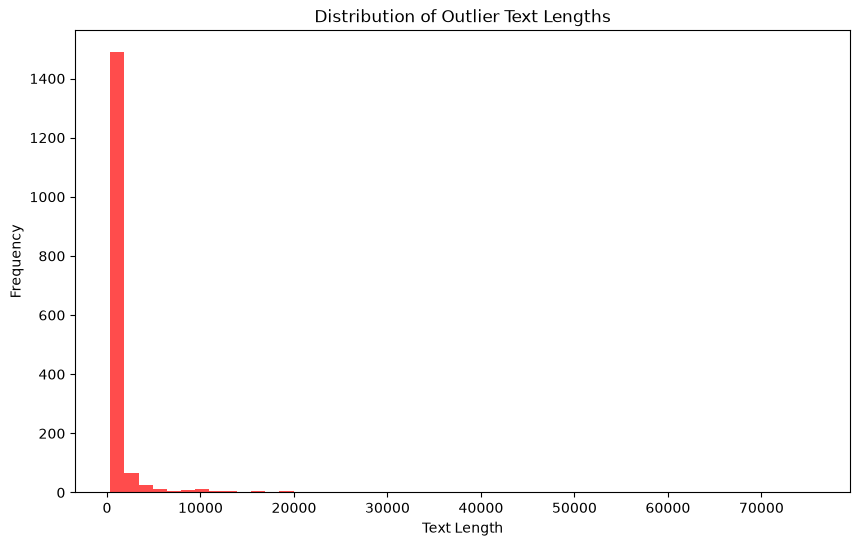

In [71]:
# the distribution is right skewed, lets sort by text length and find the outliers
outliers = df[df['Text_length'] > df['Text_length'].quantile(0.99)]
print("Number of outliers (text length > 99th percentile): {}".format(outliers.shape[0]))
# there are still many examples, lets check the distribution of the outliers
plt.figure(figsize=(10, 6))
plt.hist(outliers['Text_length'], bins=50, color='red', alpha=0.7)
plt.title('Distribution of Outlier Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

## Load tokenizer to inspect the tokens distribution

In [72]:
# login to Hugging Face using the token from the .env file
hf_token = os.getenv("HF_TOKEN")
login(token=hf_token)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [73]:
config = AutoConfig.from_pretrained("google/gemma-4-E4B")
print(config)
tokenizer = AutoTokenizer.from_pretrained("google/gemma-4-E4B")



Gemma4Config {
  "architectures": [
    "Gemma4ForConditionalGeneration"
  ],
  "audio_config": {
    "_name_or_path": "",
    "architectures": null,
    "attention_chunk_size": 12,
    "attention_context_left": 13,
    "attention_context_right": 0,
    "attention_invalid_logits_value": -1000000000.0,
    "attention_logit_cap": 50.0,
    "chunk_size_feed_forward": 0,
    "conv_kernel_size": 5,
    "dtype": "bfloat16",
    "gradient_clipping": 10000000000.0,
    "hidden_act": "silu",
    "hidden_size": 1024,
    "id2label": {
      "0": "LABEL_0",
      "1": "LABEL_1"
    },
    "initializer_range": 0.02,
    "is_encoder_decoder": false,
    "label2id": {
      "LABEL_0": 0,
      "LABEL_1": 1
    },
    "model_type": "gemma4_audio",
    "num_attention_heads": 8,
    "num_hidden_layers": 12,
    "output_attentions": false,
    "output_hidden_states": false,
    "output_proj_dims": 1536,
    "problem_type": null,
    "residual_weight": 0.5,
    "return_dict": true,
    "rms_norm_eps": 1e

## Token distribution

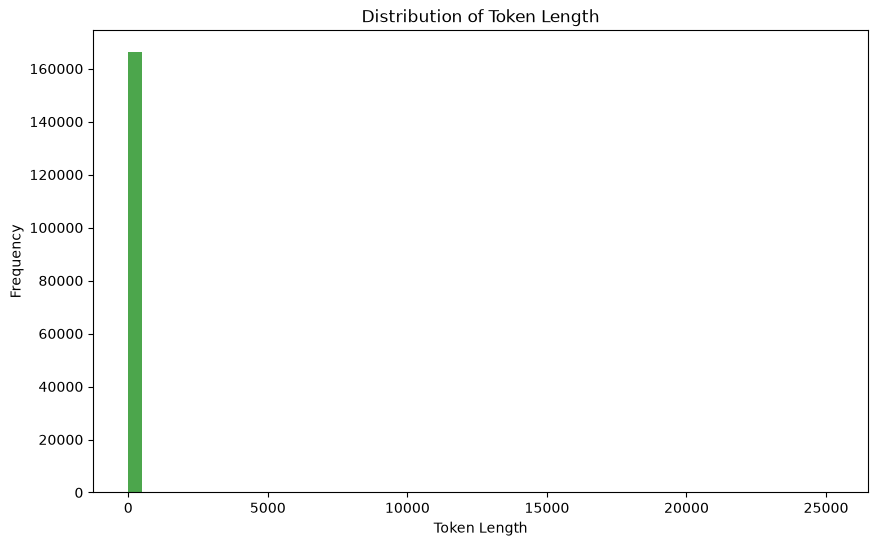

Token Length Statistics:
Mean: 29.46
Median: 20.00
Standard Deviation: 165.94
Minimum: 4
Maximum: 25247
25th Percentile: 15.0
50th Percentile (Median): 20.0
75th Percentile: 29.0
90th Percentile: 46.0
95th Percentile: 61.0
99th Percentile: 120.0


In [74]:
# create the token_length column
df['token_length'] = df['Text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))
# plot the distribution of the token length
plt.figure(figsize=(10, 6))
plt.hist(df['token_length'], bins=50, color='green', alpha=0.7)
plt.title('Distribution of Token Length')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()
# let's use df.describe() to get the counts of the token length at different percentiles
df['token_length'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print("Token Length Statistics:")
print("Mean: {:.2f}".format(df['token_length'].mean()))
print("Median: {:.2f}".format(df['token_length'].median()))
print("Standard Deviation: {:.2f}".format(df['token_length'].std()))
print("Minimum: {}".format(df['token_length'].min()))
print("Maximum: {}".format(df['token_length'].max()))
print("25th Percentile: {}".format(df['token_length'].quantile(0.25)))
print("50th Percentile (Median): {}".format(df['token_length'].quantile(0.5)))
print("75th Percentile: {}".format(df['token_length'].quantile(0.75)))
print("90th Percentile: {}".format(df['token_length'].quantile(0.9)))
print("95th Percentile: {}".format(df['token_length'].quantile(0.95)))
print("99th Percentile: {}".format(df['token_length'].quantile(0.99)))

In [75]:
# for each threshold, count the number of examples that exceed it and print the percentage
for threshold in [256, 512, 1024, 2048, 4096, 8192]:
    count = (df["token_length"] > threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"{threshold:5} tokens: "
        f"{count:6} examples ({percentage:.3f}%)"
    )

  256 tokens:    387 examples (0.233%)
  512 tokens:    203 examples (0.122%)
 1024 tokens:    111 examples (0.067%)
 2048 tokens:     68 examples (0.041%)
 4096 tokens:     32 examples (0.019%)
 8192 tokens:     14 examples (0.008%)


In [76]:
long_df = df[df["token_length"] > 2048].sort_values(
    "token_length",
    ascending=False
)

# display(long_df[["Text", "token_length"]])
# now that we found only 68 examples that exceed 2048 tokens, they represent a very small fraction of the dataset, so it is more efficient to drop them and store them aside for now
df = df[df["token_length"] <= 2048]

## token distrbution after removing outliers

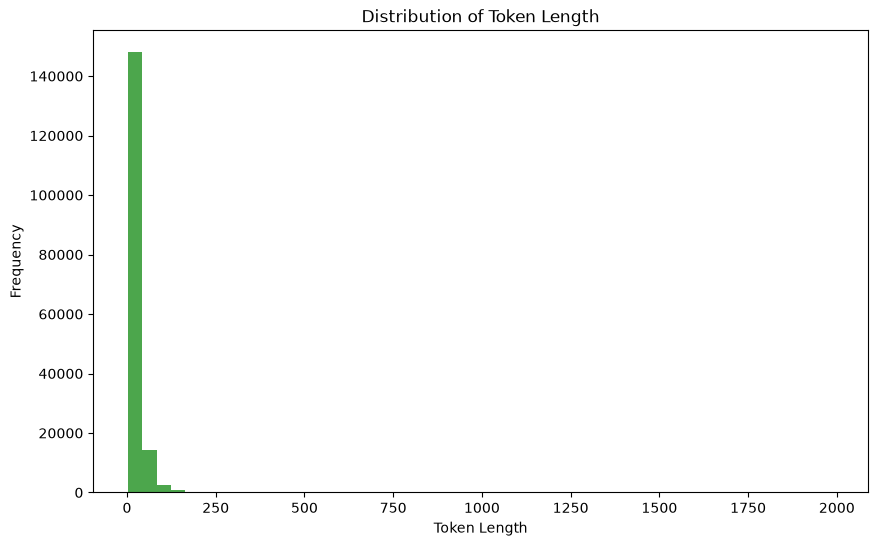

Token Length Statistics:
Mean: 27.01
Median: 20.00
Standard Deviation: 35.76
Minimum: 4
Maximum: 1989
25th Percentile: 15.0
50th Percentile (Median): 20.0
75th Percentile: 29.0
90th Percentile: 45.0
95th Percentile: 61.0
99th Percentile: 118.0


In [77]:
# plot the distribution of the token length
plt.figure(figsize=(10, 6))
plt.hist(df['token_length'], bins=50, color='green', alpha=0.7)
plt.title('Distribution of Token Length')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()
# let's use df.describe() to get the counts of the token length at different percentiles
df['token_length'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print("Token Length Statistics:")
print("Mean: {:.2f}".format(df['token_length'].mean()))
print("Median: {:.2f}".format(df['token_length'].median()))
print("Standard Deviation: {:.2f}".format(df['token_length'].std()))
print("Minimum: {}".format(df['token_length'].min()))
print("Maximum: {}".format(df['token_length'].max()))
print("25th Percentile: {}".format(df['token_length'].quantile(0.25)))
print("50th Percentile (Median): {}".format(df['token_length'].quantile(0.5)))
print("75th Percentile: {}".format(df['token_length'].quantile(0.75)))
print("90th Percentile: {}".format(df['token_length'].quantile(0.9)))
print("95th Percentile: {}".format(df['token_length'].quantile(0.95)))
print("99th Percentile: {}".format(df['token_length'].quantile(0.99)))

In [78]:
df[df["token_length"] > 256].sort_values(
    "token_length",
    ascending=False
)[["Text", "token_length"]]

Text  \
23760   تيل مع ادي you زز point نقطه نقطه ضعف هو منين يجيب البرو ولا من دي يعني يلقى معل so المصا الطرق تلونت في مشكل المشكل انه المعلومات المعلومات البارل كنحط فيديو كنت حاب يعني استند الى اهل الاختصاص ش متها ك عفا انا ماكس فيهون جبت را هذاك يح عليه وس يعني عن ورا يكون فيها الا فيها را نح المنت المربح فيها de vict resch مفقود  راح نحك على سكلا على بال فيها زق كبير الترك كيفاش تجيب يعني حوايج جينون يعني الحوايج من تركيا يعني فيوش يعني يق الواد يشوف ديو قريبا ان شاء الله ويروح يبدا يجيب سلعه من ترك ديريكت فيها كل المعلومات جبتيه انسان تعوم تعير حاكم الطريق راكم معايا وختمتها باش خدمتها باستيراد المنتجات ديكتون من الصين حلم كل التجار الالكترونيين سو نروح لها بالعقل بالعقل ونديم باسطوره المنتج المربح المنتج المربح منتج مربح انت فيها الربح والاسطوره تقول ان هذا المنتج المربح طيح عليه كزار تستي تستي تستي ش متها تيستي معها راك تجرب دي برودوي حتى وين طيح على منتج يتبع وحده فيسبوك يزيد لك الهم غير باش يمشيه مع تلون بليتي تا تشوفوا اسطوره هذ ماش مبنيه على وهمه انا بروون ش راح نقولك را نقولك بلين بروكت ولا ماين يعني المنتج المخر ولا تحب تع المنتج بحه تع الجهد اللي راح ندي في التسويق هذاك المنتج ك منتجات يع ارواحهم بارواحهم وهوك هما الين بروكت وكاين منتجات واحد اخرين اللي لازملك جد سونير باش تقنع الانسان يشرم عليك وهذاك الجهد سبمير هذاك الجهد زياده اللي راح دي في التسويق يسقم دراهم pour cest plus cest la س احكم المنتج س تعط س لو كان كان قدامك شحال تخلص ال عطيت سوبل تع تاا راك في جينون راح تلقى راس كبير يعني تلقاه   دول وان تقي بعين   هذ بعد شقين هذا cest estce que cest le time maret est que ging product prod cest حلو une fo وتكون في وقتها يعني  عن المناف المنافسه ت ميش كان نقع نعيشو كبيره وبيع حاجه كان ماقولش صغيره غيره ماتهم راح يص واحد المشكل تخلص فيسبوك يسوقك راح يطلع عشل تحوس على هدف واحد ولا حسان عم هذاك باش يشري البرو تاعك الوقت الليز بين كدير الطلبيه تا حتى نهار تلفر فيبوك را هذا اليوم عليكك يشوف كريي شباب عليه كريي فيديو ولا غو منك راح يلقى عليه ولا شوف يققل دي في بالكم التجاره الكترونيه مالازمش انمون كبير بزاف يعني اي انسان مبتدئ ما عندوش في التجاره يق يعني حساباته و الفاده تبيع فاده بزفه راح يخسر وان راح تخس يعني قبل next wi proct ما ما الموا فات ح با نق نعزز هذ المعلومه ونعطيكم جبت ضف خدمت اليوميه ولخم الخث من اكث من ك يعني اث من  منم  اوكي نستقبل الضيف تعنا صفيان دك مادام نحك على المنتج المربح ماكش انسان نعرفه في النتورك تاعي اللي راح يقدر يعطيكم كيفاش تعقل المنتج المربح ما سفيان سفيان خويا عطينا شيفر تع المنتجات المربحه اللي لقيتهم في هذ العامين شيفر تاع المتجات المرب معي في الشه يعني باذن اللهفي مزف الخدمه معهون في الجزائر سفيان ماخل سلام عليكم كيفاش تعقل المنتج المربح ولا تعقل برودوي فيه بونسي باش يولي مربح مربح مربح بالنسه لي الا هووا الوكت يعني كيكون تمشي تكونوا فيزو وين ما كانت تتلاقى به تحبس وتقول واوي الا le de compl عنفي تولي ماتوليش خدمتك انك تنوض تفتح بيسي ولا تشعل تيفون وتحوس برودوي معها تكون دور الفيد ديالك فيزو يولي ياشك ش راك حي من هذا هنا راك هضرت على في الماركيت اسداد تاعك دوندي شونسي قلت النصيحه اللي را يشوفونا في صناعه المحتوى الحاجه صنا المحتوى نحب نصنع محتوى حفاده كبيره وستعمل خدت يخج تقدر برك من هذاك عننا تيكك وعننا عن لاح انا يلات فيخل نكتب يل بعدت وراح يونك نحب نخدم حاجه مايش اول حاجه يروح ليها ك ولا روح ليها اي انسان يخدم معكوم هي روح ديدير تكري حاجه يخم فيها next li  bien donc on va dire que donc alpress يكون  عنل ز حوايج نبدا احنا نه على لديب را فيوم على بال نهب بون لازم يهبط للتيران ضسر الناس ويولي سوسيال تحب تكره لازم تخرج منتج ديالك تهبط لل المارشي تعرف بنادم يبح ريح مع في الحانو راح يعرفك بناس اتوماتي راح تعرف هذا امبور هذا تريتور وهي رايحه وهي رايحه ورايحه هذوك الناس يولوا ينقصوا عليك كامل هذاب قال تهضر مع شينوي باومل تنقص كامل هذاك نحكمو يزهم هاك برودوي جيبولي سي سمبل ما راهم يمشوا بزاف ناسك ال راك في النيفو شويه الفوق تتبدل الحكايه تولي انت وبلي ت كان عندي غير الخدمه ديي كان عندي غير لقيت روحي داخل فيشي كبير ناس كبار عنده كبير ماقدرش نون في و عل هذ الازمه ان راسي يخدم بواحد لافا ما كتش نتوقع ان نكري حاجه راني توج فيها وختها برسيب مايش في المارشي حاسس جتل عنبرا روحي باش نقدر نجي فيب ديالك ما تكريش عندك فيش قدامك تون الناس بزاف ماافهم وتتكل على ربي تقح تتعامل مع ناس يجيبك س و قبل ما تشر

# Splitting based on scripts arabic and latin

In [79]:
# We now split the dataset based on the scripts arabic vs latin, for examples that contain a mix of both we include them in the second dataset which we will handle in stage 2
arabic_df = df[df["Text"].apply(lambda x: any('\u0600' <= c <= '\u06FF' for c in x))]
latin_df = df[~df.index.isin(arabic_df.index)]
print("Arabic dataset shape: {}".format(arabic_df.shape))
print("Latin dataset shape: {}".format(latin_df.shape))

Arabic dataset shape: (137064, 3)
Latin dataset shape: (29181, 3)


In [80]:
latin_df.head

<bound method NDFrame.head of                                                                                                                                                                                                          Text  \
0                                                                                                                                                                  Una delle cose più belle sentire il Coran    
12                                                                                                                     jai  ans jai fait que Anglais LV je comprends exactement ce quil dit x mais pas grave    
20                                                                                                                                                   Girl skate mart Swilah hiya la réalisatrice Fatma Blhaj    
26                                                                                  Quand je vois des jeunes intelligents motives et p